In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



***Load Dataset***

In [5]:
(X_train, y_train), (X_test, y_test) = imdb.load_data()

print("Training Reviews :", len(X_train))
print("Testing Reviews  :", len(X_test))

Training Reviews : 25000
Testing Reviews  : 25000


***Total No.of Reviews***

In [6]:
total_reviews = len(X_train) + len(X_test)
print("Total Reviews:", total_reviews)

Total Reviews: 50000


***Positive and Negetive Reviews***

In [7]:
all_labels = np.concatenate([y_train, y_test])
positive_reviews = np.sum(all_labels)
negative_reviews = len(all_labels) - positive_reviews
print("Positive Reviews :", positive_reviews)
print("Negative Reviews :", negative_reviews)

Positive Reviews : 25000
Negative Reviews : 25000


***Average Review Length***

In [8]:
all_reviews = X_train + X_test
review_lengths = [len(review) for review in all_reviews]
average_length = np.mean(review_lengths)
print("Average Review Length:", average_length)

Average Review Length: 469.51784


***Longest Review***

In [9]:
longest_review = max(review_lengths)
print("Longest Review Length:", longest_review)

Longest Review Length: 2697


***Shortest Review***

In [10]:
shortest_review = min(review_lengths)
print("Shortest Review Length:", shortest_review)

Shortest Review Length: 70


***Dataset Summary***

In [11]:
print("\nDATASET SUMMARY")
print("-" * 40)
print("Total Reviews       :", total_reviews)
print("Positive Reviews    :", positive_reviews)
print("Negative Reviews    :", negative_reviews)
print("Average Length      :", round(average_length, 2))
print("Longest Review      :", longest_review)
print("Shortest Review     :", shortest_review)


DATASET SUMMARY
----------------------------------------
Total Reviews       : 50000
Positive Reviews    : 25000
Negative Reviews    : 25000
Average Length      : 469.52
Longest Review      : 2697
Shortest Review     : 70


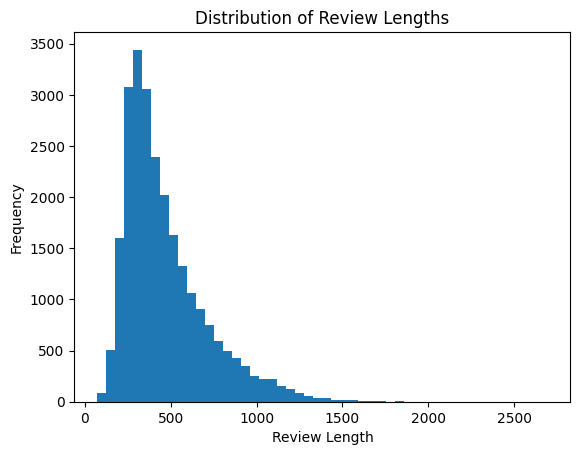

In [12]:
import matplotlib.pyplot as plt

plt.hist(review_lengths, bins=50)
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.title("Distribution of Review Lengths")
plt.show()

***Import Libraries***

In [13]:
import re
import string
import nltk

from nltk.corpus import stopwords
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\spand\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

***Load Dataset***

In [14]:
max_features = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=max_features
)

print("Training Reviews:", len(X_train))
print("Testing Reviews :", len(X_test))

Training Reviews: 25000
Testing Reviews : 25000


***Integer sequences to Text***

In [15]:
word_index = imdb.get_word_index()
reverse_word_index = {
    value + 3: key
    for key, value in word_index.items()
}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(review):
    return " ".join(
        reverse_word_index.get(i, "?")
        for i in review
    )
reviews_text = [decode_review(review) for review in X_train]

***Lowercase Conversion***

In [16]:
reviews_text = [review.lower() for review in reviews_text]

***HTML Tag Removal***

In [17]:
def remove_html(text):
    return re.sub(r'<.*?>', '', text)

reviews_text = [remove_html(review) for review in reviews_text]

***Punctuation Removal***

In [18]:
def remove_punctuation(text):
    return text.translate(
        str.maketrans('', '', string.punctuation)
    )

reviews_text = [
    remove_punctuation(review)
    for review in reviews_text
]

***Stopword Removal***

In [19]:
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    words = text.split()
    filtered_words = [
        word for word in words
        if word not in stop_words
    ]
    return " ".join(filtered_words)

reviews_text = [
    remove_stopwords(review)
    for review in reviews_text
]

***Tokenization***

In [20]:
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(reviews_text)
sequences = tokenizer.texts_to_sequences(
    reviews_text
)

***Sequence Generation***

In [21]:
print("Sample Sequence:")
print(sequences[0][:20])

Sample Sequence:
[4, 420, 849, 1489, 1255, 11, 348, 4310, 12, 3793, 78, 155, 28, 719, 554, 370, 180, 74, 229, 277]


***Padding***

In [22]:
max_length = 200

X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print(X_train.shape)
print(X_test.shape)

(25000, 200)
(25000, 200)


***Simple RNN***

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

***Split Data***

In [24]:
print(X_train)
print(X_test)
print(y_train)
print(y_test)

[[   1   14   22 ...  226   65   16]
 [   1  194 1153 ...    0    0    0]
 [   1   14   47 ...    0    0    0]
 ...
 [   1   11    6 ...    0    0    0]
 [   1 1446 7079 ...    0    0    0]
 [   1   17    6 ...    0    0    0]]
[[   1  591  202 ...    0    0    0]
 [   1   14   22 ... 2033   19 7836]
 [   1  111  748 ...  655 2212    5]
 ...
 [   1   13 1408 ...    0    0    0]
 [   1   11  119 ...    0    0    0]
 [   1    6   52 ...    0    0    0]]
[1 0 0 ... 0 1 0]
[0 1 1 ... 0 0 0]


***Simple RNN Model***

In [25]:
rnn_model = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=16,
        input_length=max_length
    ),

    SimpleRNN(32),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

C:\Users\spand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


***Model Summary***

In [26]:
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

***Compile Model***

In [27]:
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

***Train Model***

In [28]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.5049 - loss: 0.6938 - val_accuracy: 0.5004 - val_loss: 0.6954
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.5382 - loss: 0.6867 - val_accuracy: 0.5136 - val_loss: 0.6963
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 70ms/step - accuracy: 0.6110 - loss: 0.6240 - val_accuracy: 0.5395 - val_loss: 0.7058
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.7015 - loss: 0.4747 - val_accuracy: 0.5057 - val_loss: 0.9128
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.7315 - loss: 0.4038 - val_accuracy: 0.5181 - val_loss: 1.0916


***Evaluate the Model***

In [29]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(
    X_test,
    y_test
)

print("SimpleRNN Accuracy:", rnn_accuracy)
print("SimpleRNN Loss:", rnn_loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5181 - loss: 1.0916
SimpleRNN Accuracy: 0.5181199908256531
SimpleRNN Loss: 1.091596245765686


***Predict Sentiment***

In [30]:
def predict_sentiment(model, review):
    padded = pad_sequences(
        [review],
        maxlen=max_length,
        padding='post',
        truncating='post'
    )
    prediction = model.predict(
        padded,
        verbose=0
    )[0][0]

    if prediction >= 0.5:
        return "Positive"
    else:
        return "Negative"

***Test Prediction***

In [31]:
sample_review = X_test[0]
result = predict_sentiment(
    rnn_model,
    sample_review
)
print("Prediction:", result)

Prediction: Positive


***LSTM Model***


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_model = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=16,
        input_length=max_length
    ),

    LSTM(32),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

***Compile LSTM***

In [33]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

***Train LSTM***

In [34]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 88ms/step - accuracy: 0.5435 - loss: 0.6840 - val_accuracy: 0.5510 - val_loss: 0.6842
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step - accuracy: 0.5754 - loss: 0.6726 - val_accuracy: 0.5931 - val_loss: 0.6734
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.6152 - loss: 0.6522 - val_accuracy: 0.5432 - val_loss: 0.6827
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 54ms/step - accuracy: 0.6599 - loss: 0.5936 - val_accuracy: 0.7341 - val_loss: 0.5809
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 54ms/step - accuracy: 0.8544 - loss: 0.3464 - val_accuracy: 0.8360 - val_loss: 0.3743


***Evaluate LSTM***

In [35]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_test,
    y_test
)

print("LSTM Accuracy:", lstm_accuracy)
print("LSTM Loss:", lstm_loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8360 - loss: 0.3743
LSTM Accuracy: 0.8360000252723694
LSTM Loss: 0.37425801157951355


***GRU Model***

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

gru_model = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=16,
        input_length=max_length
    ),

    GRU(32),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

***Compile GRU***

In [37]:
gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

***Train GRU***

In [38]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 87ms/step - accuracy: 0.5164 - loss: 0.6896 - val_accuracy: 0.5038 - val_loss: 0.6919
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 98ms/step - accuracy: 0.5725 - loss: 0.6682 - val_accuracy: 0.7234 - val_loss: 0.5482
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.7830 - loss: 0.4526 - val_accuracy: 0.8502 - val_loss: 0.3424
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.8962 - loss: 0.2580 - val_accuracy: 0.8541 - val_loss: 0.3397
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.9280 - loss: 0.1931 - val_accuracy: 0.8587 - val_loss: 0.3536


***Evaluate GRU***

In [39]:
gru_loss, gru_accuracy = gru_model.evaluate(
    X_test,
    y_test
)

print("GRU Accuracy:", gru_accuracy)
print("GRU Loss:", gru_loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8587 - loss: 0.3536
GRU Accuracy: 0.8587200045585632
GRU Loss: 0.3535608649253845


***Compare all models***

In [40]:
print("\nMODEL COMPARISON")
print("-" * 40)

print("SimpleRNN Accuracy :", rnn_accuracy)
print("LSTM Accuracy      :", lstm_accuracy)
print("GRU Accuracy       :", gru_accuracy)

print("\nSimpleRNN Loss     :", rnn_loss)
print("LSTM Loss          :", lstm_loss)
print("GRU Loss           :", gru_loss)


MODEL COMPARISON
----------------------------------------
SimpleRNN Accuracy : 0.5181199908256531
LSTM Accuracy      : 0.8360000252723694
GRU Accuracy       : 0.8587200045585632

SimpleRNN Loss     : 1.091596245765686
LSTM Loss          : 0.37425801157951355
GRU Loss           : 0.3535608649253845


***Accuracy comparision graph***

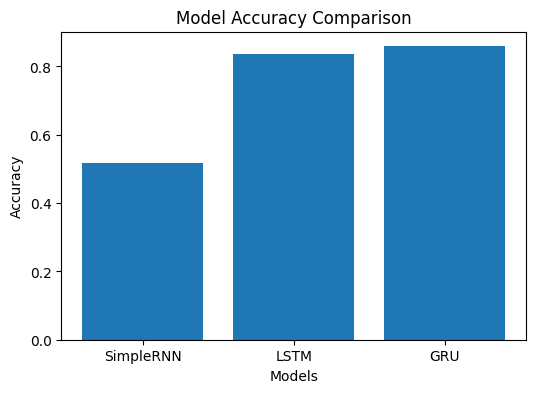

In [41]:
import matplotlib.pyplot as plt

models = ['SimpleRNN', 'LSTM', 'GRU']
accuracies = [
    rnn_accuracy,
    lstm_accuracy,
    gru_accuracy
]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

***Import Metrics***

In [42]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import time
import pandas as pd

***Simple RNN Training Time***

In [43]:
start = time.time()

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

rnn_time = time.time() - start

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.7456 - loss: 0.3727 - val_accuracy: 0.5166 - val_loss: 1.3493
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.7554 - loss: 0.3691 - val_accuracy: 0.5056 - val_loss: 1.3844
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.7637 - loss: 0.3561 - val_accuracy: 0.5134 - val_loss: 1.4497


***LSTM Training Time***

In [44]:
start = time.time()

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

lstm_time = time.time() - start

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.9067 - loss: 0.2459 - val_accuracy: 0.8038 - val_loss: 0.5446
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.9273 - loss: 0.1975 - val_accuracy: 0.8554 - val_loss: 0.3771
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 67ms/step - accuracy: 0.9511 - loss: 0.1481 - val_accuracy: 0.8504 - val_loss: 0.4283


***GRU Training Time***

In [45]:
start = time.time()

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

gru_time = time.time() - start

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 76ms/step - accuracy: 0.9470 - loss: 0.1492 - val_accuracy: 0.8539 - val_loss: 0.3737
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.9630 - loss: 0.1099 - val_accuracy: 0.8475 - val_loss: 0.4405
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.9759 - loss: 0.0778 - val_accuracy: 0.8427 - val_loss: 0.5374


In [47]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

***Generate Predictions***

In [48]:
rnn_pred = rnn_model.predict(X_test, verbose=0)
rnn_pred = (rnn_pred > 0.5).astype(int).flatten()

In [49]:
lstm_pred = lstm_model.predict(X_test, verbose=0)
lstm_pred = (lstm_pred > 0.5).astype(int).flatten()


In [50]:
gru_pred = gru_model.predict(X_test, verbose=0)
gru_pred = (gru_pred > 0.5).astype(int).flatten()

***Simple RNN Metrics***

In [52]:
rnn_accuracy = accuracy_score(y_test, rnn_pred)
rnn_precision = precision_score(y_test, rnn_pred)
rnn_recall = recall_score(y_test, rnn_pred)
rnn_f1 = f1_score(y_test, rnn_pred)

***LSTM Metrics***

In [53]:
lstm_accuracy = accuracy_score(y_test, lstm_pred)
lstm_precision = precision_score(y_test, lstm_pred)
lstm_recall = recall_score(y_test, lstm_pred)
lstm_f1 = f1_score(y_test, lstm_pred)

***GRU Metrics***

In [54]:
gru_accuracy = accuracy_score(y_test, gru_pred)
gru_precision = precision_score(y_test, gru_pred)
gru_recall = recall_score(y_test, gru_pred)
gru_f1 = f1_score(y_test, gru_pred)

***Parameters***

In [55]:
rnn_params = rnn_model.count_params()
lstm_params = lstm_model.count_params()
gru_params = gru_model.count_params()

***Comparision Table***

In [56]:
comparison = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time",
        "Validation Accuracy",
        "Validation Loss",
        "Parameters"
    ],

    "SimpleRNN":[
        rnn_accuracy,
        rnn_precision,
        rnn_recall,
        rnn_f1,
        rnn_time,
        max(history_rnn.history['val_accuracy']),
        min(history_rnn.history['val_loss']),
        rnn_params
    ],

    "LSTM":[
        lstm_accuracy,
        lstm_precision,
        lstm_recall,
        lstm_f1,
        lstm_time,
        max(history_lstm.history['val_accuracy']),
        min(history_lstm.history['val_loss']),
        lstm_params
    ],

    "GRU":[
        gru_accuracy,
        gru_precision,
        gru_recall,
        gru_f1,
        gru_time,
        max(history_gru.history['val_accuracy']),
        min(history_gru.history['val_loss']),
        gru_params
    ]
})

print(comparison)

                Metric      SimpleRNN           LSTM            GRU
0             Accuracy       0.513360       0.850400       0.842680
1            Precision       0.519257       0.825312       0.864522
2               Recall       0.360240       0.888960       0.812720
3             F1 Score       0.425373       0.855954       0.837821
4        Training Time      85.937154     149.819669     182.939904
5  Validation Accuracy       0.516600       0.855440       0.853880
6      Validation Loss       1.349299       0.377121       0.373731
7           Parameters  162113.000000  166817.000000  165345.000000


***Accuracy Comparision Graph***

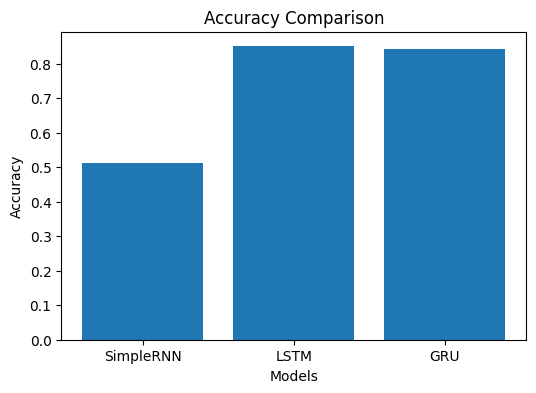

In [57]:
import matplotlib.pyplot as plt

models = ["SimpleRNN","LSTM","GRU"]

accuracies = [
    rnn_accuracy,
    lstm_accuracy,
    gru_accuracy
]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

***Loss Comparision Graph***

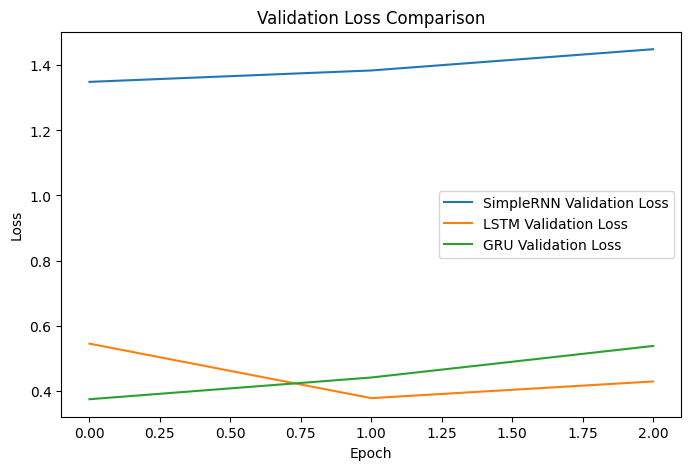

In [58]:
plt.figure(figsize=(8,5))

plt.plot(
    history_rnn.history['val_loss'],
    label='SimpleRNN Validation Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='LSTM Validation Loss'
)

plt.plot(
    history_gru.history['val_loss'],
    label='GRU Validation Loss'
)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

***Training Accuracy Graph***

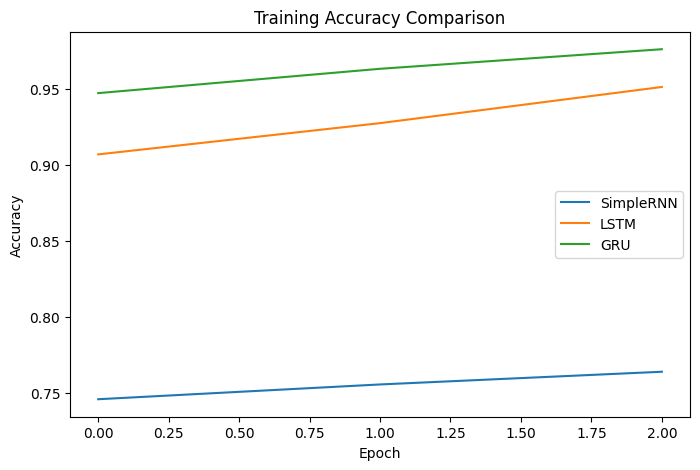

In [59]:
plt.figure(figsize=(8,5))

plt.plot(
    history_rnn.history['accuracy'],
    label='SimpleRNN'
)

plt.plot(
    history_lstm.history['accuracy'],
    label='LSTM'
)

plt.plot(
    history_gru.history['accuracy'],
    label='GRU'
)

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

***Training Time Graph***

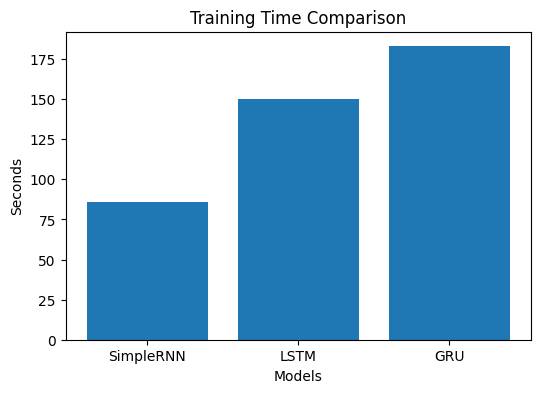

In [60]:
times = [
    rnn_time,
    lstm_time,
    gru_time
]

plt.figure(figsize=(6,4))

plt.bar(
    models,
    times
)

plt.title("Training Time Comparison")
plt.xlabel("Models")
plt.ylabel("Seconds")

plt.show()

***Decode user review***

In [61]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

word_index = imdb.get_word_index()

tokenizer = Tokenizer(num_words=10000)
tokenizer.word_index = word_index

***Prediction Function***

In [62]:
def predict_sentiment(model, text):

    sequence = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    score = model.predict(
        padded,
        verbose=0
    )[0][0]

    sentiment = "Positive" if score >= 0.5 else "Negative"

    return sentiment, score

***Test Review1***

In [63]:
review1 = "This movie was absolutely fantastic and I enjoyed every minute."

print("Review 1")

print(
    "RNN:",
    predict_sentiment(rnn_model, review1)
)

print(
    "LSTM:",
    predict_sentiment(lstm_model, review1)
)

print(
    "GRU:",
    predict_sentiment(gru_model, review1)
)

Review 1
RNN: ('Negative', np.float32(0.47864476))
LSTM: ('Negative', np.float32(0.14565095))
GRU: ('Negative', np.float32(0.12267581))


***Test Review2***

In [64]:
review2 = "The movie was boring and a complete waste of time."

print("Review 2")

print(
    "RNN:",
    predict_sentiment(rnn_model, review2)
)

print(
    "LSTM:",
    predict_sentiment(lstm_model, review2)
)

print(
    "GRU:",
    predict_sentiment(gru_model, review2)
)

Review 2
RNN: ('Negative', np.float32(0.47761995))
LSTM: ('Positive', np.float32(0.96845835))
GRU: ('Positive', np.float32(0.99261874))


***Test Review3***

In [65]:
review3 = "The acting was good but the story was average."

print("Review 3")

print(
    "RNN:",
    predict_sentiment(rnn_model, review3)
)

print(
    "LSTM:",
    predict_sentiment(lstm_model, review3)
)

print(
    "GRU:",
    predict_sentiment(gru_model, review3)
)

Review 3
RNN: ('Negative', np.float32(0.4736219))
LSTM: ('Positive', np.float32(0.5433848))
GRU: ('Positive', np.float32(0.99270797))


In [69]:
rnn_model.save("rnn_model.keras")

lstm_model.save("lstm_model.keras")

gru_model.save("gru_model.keras")

In [70]:
import os

print(os.path.getsize("rnn_model.keras"))
print(os.path.getsize("lstm_model.keras"))
print(os.path.getsize("gru_model.keras"))

1978030
2034550
2016879
